# Test de fidelidad para ts-MULE

Este cuaderno evalúa si la explicación local reproduce el comportamiento del modelo mediante dos pruebas:

1. **R² del surrogate local**: `LimeTS` ajusta una regresión sobre perturbaciones y calcula R² en un 30% reservado. Un valor más alto indica mayor fidelidad local.
2. **Deletion/Insertion por segmento**: se ordenan los segmentos por `|relevancia|`. En *deletion* se eliminan desde el más relevante; en *insertion* se restauran desde el más relevante.

Interpretación: **R² alto**, **Deletion AUC bajo** e **Insertion AUC alto** son deseables. Las curvas usan directamente la probabilidad entregada por el clasificador.

In [2]:
from pathlib import Path
import sys
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso

# Funciona tanto dentro del repositorio como desde otra carpeta.
PROJECT_ROOT = Path.cwd()

sys.path.insert(0, str(PROJECT_ROOT / 'METHODS' / 'ts-mule'))
warnings.filterwarnings('ignore', category=RuntimeWarning)

from keras.models import load_model
from tsmule.xai.lime import LimeTS
from tsmule.sampling import replace as replacement

print('Proyecto:', PROJECT_ROOT)

2026-06-24 01:14:14.356208: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-24 01:14:14.411994: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-06-24 01:14:15.486421: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Proyecto: /home/ignacio/Proyectos/Proyecto-XAI-2026-main


## 1. Cargar modelo y muestra

Los parámetros replican la implementación actual. Para el análisis final se puede aumentar `N_RUNS`; 20 permite comprobar el flujo sin convertir el notebook en una prueba de paciencia.

In [3]:
with open(PROJECT_ROOT / 'DATA' / 'xtest_new.pickle', 'rb') as file:
    X_test = pickle.load(file)

model = load_model(PROJECT_ROOT / 'MODELS' / 'transfer_learned_tsunami_classifier.keras')

SAMPLE_INDEX = 1
N_RUNS = 20
N_SAMPLES = 100
PARTITIONS = 5
WIN_LENGTH = 4
ALPHA = 1e-4
SEGMENTATION_METHOD = 'slopes-sorted'
REPLACE_METHOD = 'zeros'
RANDOM_SEED = 42

x = np.asarray(X_test[SAMPLE_INDEX], dtype=float)
feature_names = [f'Boya {i + 1}' for i in range(x.shape[1])]

def predict_proba(x_input):
    x_input = np.asarray(x_input)
    if x_input.ndim == 2:
        x_input = x_input[np.newaxis, ...]
    # El modelo fue guardado con una lista de una entrada: ['conv1d_1_input'].
    prediction = model([x_input], training=False)
    return np.asarray(prediction).reshape(-1)

print('Shape:', x.shape)
print('Predicción original:', predict_proba(x)[0])

I0000 00:00:1782278056.559221   54189 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5704 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2080, pci bus id: 0000:01:00.0, compute capability: 7.5


Shape: (241, 6)


2026-06-24 01:14:36.938432: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 92300


Predicción original: 0.99999976


## 2. R² del surrogate local

`LimeTS` ya calcula esta métrica con un split local 70/30. Se repite la explicación para observar su estabilidad y se promedian las relevancias para la prueba posterior.

In [4]:
np.random.seed(RANDOM_SEED)
relevances, local_r2 = [], []

for run in range(N_RUNS):
    explainer = LimeTS(
        n_samples=N_SAMPLES,
        partitions=PARTITIONS,
        win_length=WIN_LENGTH,
        kernel=Lasso(alpha=ALPHA),
        replace_method=REPLACE_METHOD,
    )
    relevance = explainer.explain(
        x,
        predict_proba,
        segmentation_method=SEGMENTATION_METHOD,
    )
    relevances.append(relevance)
    local_r2.append(explainer.score)

relevance_mean = np.mean(relevances, axis=0)
segments = explainer._segmenter.segment(x, segmentation_method=SEGMENTATION_METHOD)
local_r2 = np.asarray(local_r2)

pd.Series(local_r2, name='R² local').describe().to_frame()

,R² local
count,20.000000
mean,-0.727686
std,0.710496
min,-2.355074
25%,-0.979580
50%,-0.509038
75%,-0.224862
max,0.148987


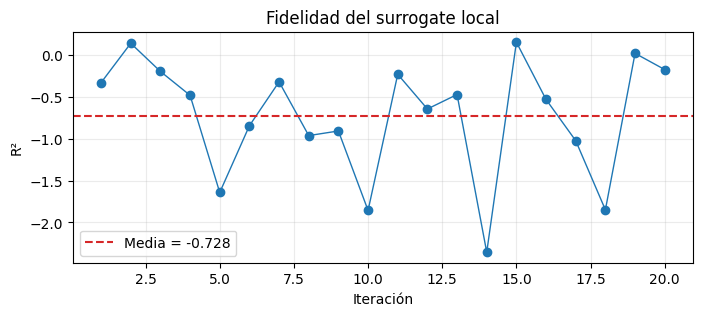

In [5]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(range(1, N_RUNS + 1), local_r2, marker='o', linewidth=1)
ax.axhline(local_r2.mean(), color='tab:red', linestyle='--', label=f'Media = {local_r2.mean():.3f}')
ax.set(xlabel='Iteración', ylabel='R²', title='Fidelidad del surrogate local')
ax.grid(alpha=.25)
ax.legend()
plt.show()

## 3. Deletion/Insertion a nivel de segmento

Cada etiqueta de la segmentación ts-MULE se considera una unidad. La prueba base ordena por `|relevancia|`. La prueba adicional ordena primero los segmentos con relevancia positiva para la clase predicha, es decir, la evidencia que sostiene esa predicción.

In [6]:
def segment_ranking(relevance, segment_mask, ranking='absolute', target_sign=1):
    labels = np.unique(segment_mask)

    if ranking == 'absolute':
        importance = np.array([
            np.mean(np.abs(relevance[segment_mask == label]))
            for label in labels
        ])
        order = np.argsort(importance)[::-1]
        return labels[order], importance[order]

    if ranking == 'positive_first':
        signed = np.array([
            target_sign * np.mean(relevance[segment_mask == label])
            for label in labels
        ])
        positives = np.where(signed > 0)[0]
        others = np.where(signed <= 0)[0]
        order = np.r_[
            positives[np.argsort(signed[positives])[::-1]],
            others[np.argsort(np.abs(signed[others]))[::-1]],
        ]
        return labels[order], signed[order]

    raise ValueError(f'ranking desconocido: {ranking}')


def deletion_insertion_curves(
    x, relevance, segment_mask, predict_fn, replace_method='zeros',
    ranking='absolute', target_sign=1,
):
    ordered_labels, importance = segment_ranking(
        relevance, segment_mask, ranking=ranking, target_sign=target_sign
    )
    baseline = getattr(replacement, replace_method)(x, segment_mask)

    deleted = x.copy()
    inserted = baseline.copy()
    deletion_batch = [deleted.copy()]
    insertion_batch = [inserted.copy()]

    for label in ordered_labels:
        mask = segment_mask == label
        deleted[mask] = baseline[mask]
        inserted[mask] = x[mask]
        deletion_batch.append(deleted.copy())
        insertion_batch.append(inserted.copy())

    fractions = np.arange(len(ordered_labels) + 1) / len(ordered_labels)
    deletion_score = predict_fn(np.asarray(deletion_batch))
    insertion_score = predict_fn(np.asarray(insertion_batch))

    # La orientación de los extremos es parte del test, no decoración.
    assert np.allclose(deletion_batch[0], x)
    assert np.allclose(deletion_batch[-1], baseline)
    assert np.allclose(insertion_batch[0], baseline)
    assert np.allclose(insertion_batch[-1], x)

    return {
        'fractions': fractions,
        'deletion': deletion_score,
        'insertion': insertion_score,
        'deletion_auc': np.trapezoid(deletion_score, fractions),
        'insertion_auc': np.trapezoid(insertion_score, fractions),
        'ordered_labels': ordered_labels,
        'importance': importance,
        'baseline_prediction': insertion_score[0],
        'original_prediction': deletion_score[0],
    }


fidelity = deletion_insertion_curves(
    x, relevance_mean, segments, predict_proba, REPLACE_METHOD
)
target_sign = 1 if fidelity['original_prediction'] >= 0.5 else -1
fidelity_positive_first = deletion_insertion_curves(
    x, relevance_mean, segments, predict_proba, REPLACE_METHOD,
    ranking='positive_first', target_sign=target_sign,
)

pd.Series({
    'R² local medio': local_r2.mean(),
    'R² local std': local_r2.std(ddof=1),
    'Deletion AUC ↓': fidelity['deletion_auc'],
    'Insertion AUC ↑': fidelity['insertion_auc'],
    'Gap insertion - deletion ↑': fidelity['insertion_auc'] - fidelity['deletion_auc'],
    'Deletion AUC positivo primero ↓': fidelity_positive_first['deletion_auc'],
    'Insertion AUC positivo primero ↑': fidelity_positive_first['insertion_auc'],
    'Predicción original': fidelity['original_prediction'],
    'Predicción baseline': fidelity['baseline_prediction'],
}, name='valor').to_frame()

,valor
R² local medio,-0.727686
R² local std,0.710496
Deletion AUC ↓,0.674920
Insertion AUC ↑,0.803932
Gap insertion - deletion ↑,0.129012
Deletion AUC positivo primero ↓,0.502552
Insertion AUC positivo primero ↑,0.975365
Predicción original,1.000000
Predicción baseline,0.008418


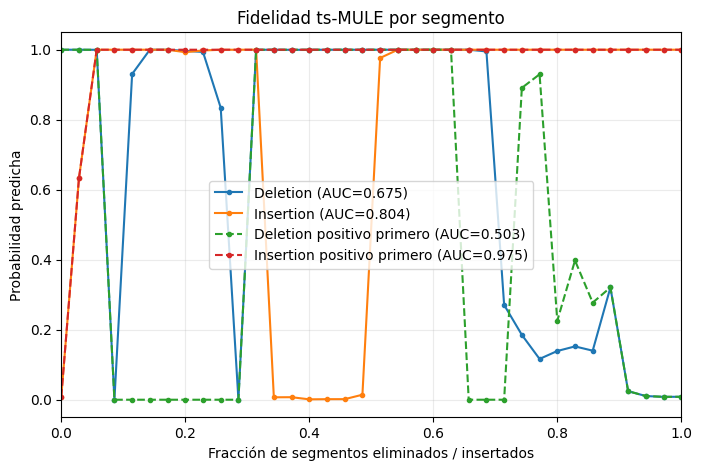

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(fidelity['fractions'], fidelity['deletion'], marker='o', markersize=3,
        label=f"Deletion (AUC={fidelity['deletion_auc']:.3f})")
ax.plot(fidelity['fractions'], fidelity['insertion'], marker='o', markersize=3,
        label=f"Insertion (AUC={fidelity['insertion_auc']:.3f})")
ax.plot(fidelity_positive_first['fractions'], fidelity_positive_first['deletion'],
        marker='o', markersize=3, linestyle='--',
        label=f"Deletion positivo primero (AUC={fidelity_positive_first['deletion_auc']:.3f})")
ax.plot(fidelity_positive_first['fractions'], fidelity_positive_first['insertion'],
        marker='o', markersize=3, linestyle='--',
        label=f"Insertion positivo primero (AUC={fidelity_positive_first['insertion_auc']:.3f})")
ax.set(
    xlabel='Fracción de segmentos eliminados / insertados',
    ylabel='Probabilidad predicha',
    title='Fidelidad ts-MULE por segmento',
    xlim=(0, 1),
)
ax.grid(alpha=.25)
ax.legend()
plt.show()

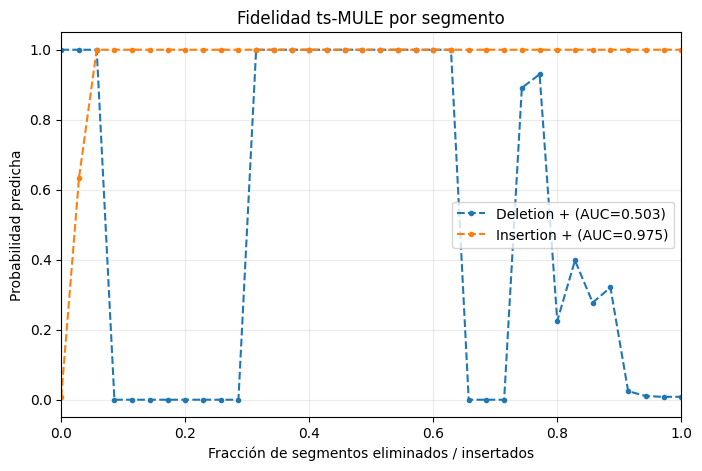

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(fidelity_positive_first['fractions'], fidelity_positive_first['deletion'],
        marker='o', markersize=3, linestyle='--',
        label=f"Deletion + (AUC={fidelity_positive_first['deletion_auc']:.3f})")
ax.plot(fidelity_positive_first['fractions'], fidelity_positive_first['insertion'],
        marker='o', markersize=3, linestyle='--',
        label=f"Insertion + (AUC={fidelity_positive_first['insertion_auc']:.3f})")
ax.set(
    xlabel='Fracción de segmentos eliminados / insertados',
    ylabel='Probabilidad predicha',
    title='Fidelidad ts-MULE por segmento',
    xlim=(0, 1),
)
ax.grid(alpha=.25)
ax.legend()
plt.show()

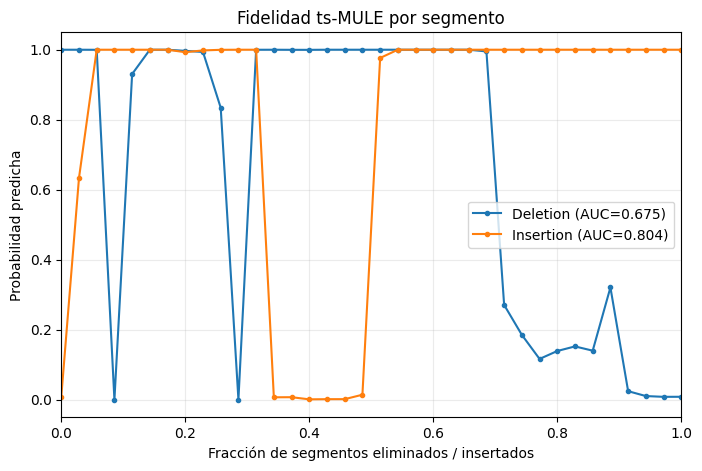

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(fidelity['fractions'], fidelity['deletion'], marker='o', markersize=3,
        label=f"Deletion (AUC={fidelity['deletion_auc']:.3f})")
ax.plot(fidelity['fractions'], fidelity['insertion'], marker='o', markersize=3,
        label=f"Insertion (AUC={fidelity['insertion_auc']:.3f})")
ax.set(
    xlabel='Fracción de segmentos eliminados / insertados',
    ylabel='Probabilidad predicha',
    title='Fidelidad ts-MULE por segmento',
    xlim=(0, 1),
)
ax.grid(alpha=.25)
ax.legend()
plt.show()

## 4. Segmentos más influyentes

Esta tabla permite auditar qué partes de cada boya determinan el orden usado en las curvas.

In [10]:
rows = []
for rank, (label, importance) in enumerate(
    zip(fidelity['ordered_labels'], fidelity['importance']), start=1
):
    positions = np.argwhere(segments == label)
    time_idx = positions[:, 0]
    feature_idx = int(positions[0, 1])
    rows.append({
        'rank': rank,
        'segmento': int(label),
        'feature': feature_names[feature_idx],
        'inicio': int(time_idx.min()),
        'fin': int(time_idx.max()),
        '|relevancia| media': importance,
        'relevancia firmada': float(np.mean(relevance_mean[segments == label])),
    })

segment_table = pd.DataFrame(rows)
segment_table.head(15)

,rank,segmento,feature,inicio,fin,|relevancia| media,relevancia firmada
0,1,14,Boya 3,0,36,0.129486,0.129486
1,2,5,Boya 1,106,240,0.120270,0.120270
2,3,35,Boya 6,0,22,0.114087,0.114087
3,4,29,Boya 5,0,56,0.100451,-0.100451
4,5,18,Boya 3,73,186,0.088491,-0.088491
5,6,2,Boya 1,65,87,0.079130,-0.079130
6,7,26,Boya 4,120,240,0.076332,-0.076332
7,8,23,Boya 4,63,77,0.062386,0.062386
8,9,11,Boya 2,113,233,0.059706,0.059706
9,10,0,Boya 1,0,62,0.057065,0.057065


## 5. Zonas modificadas y efecto sobre la categorización

Las siguientes figuras comparan la serie original (gris) con la serie modificada (color). El sombreado rojo identifica exactamente las zonas eliminadas o todavía no insertadas. Cada fila informa la fracción de segmentos manipulados, la probabilidad resultante y la categoría obtenida con un umbral configurable.

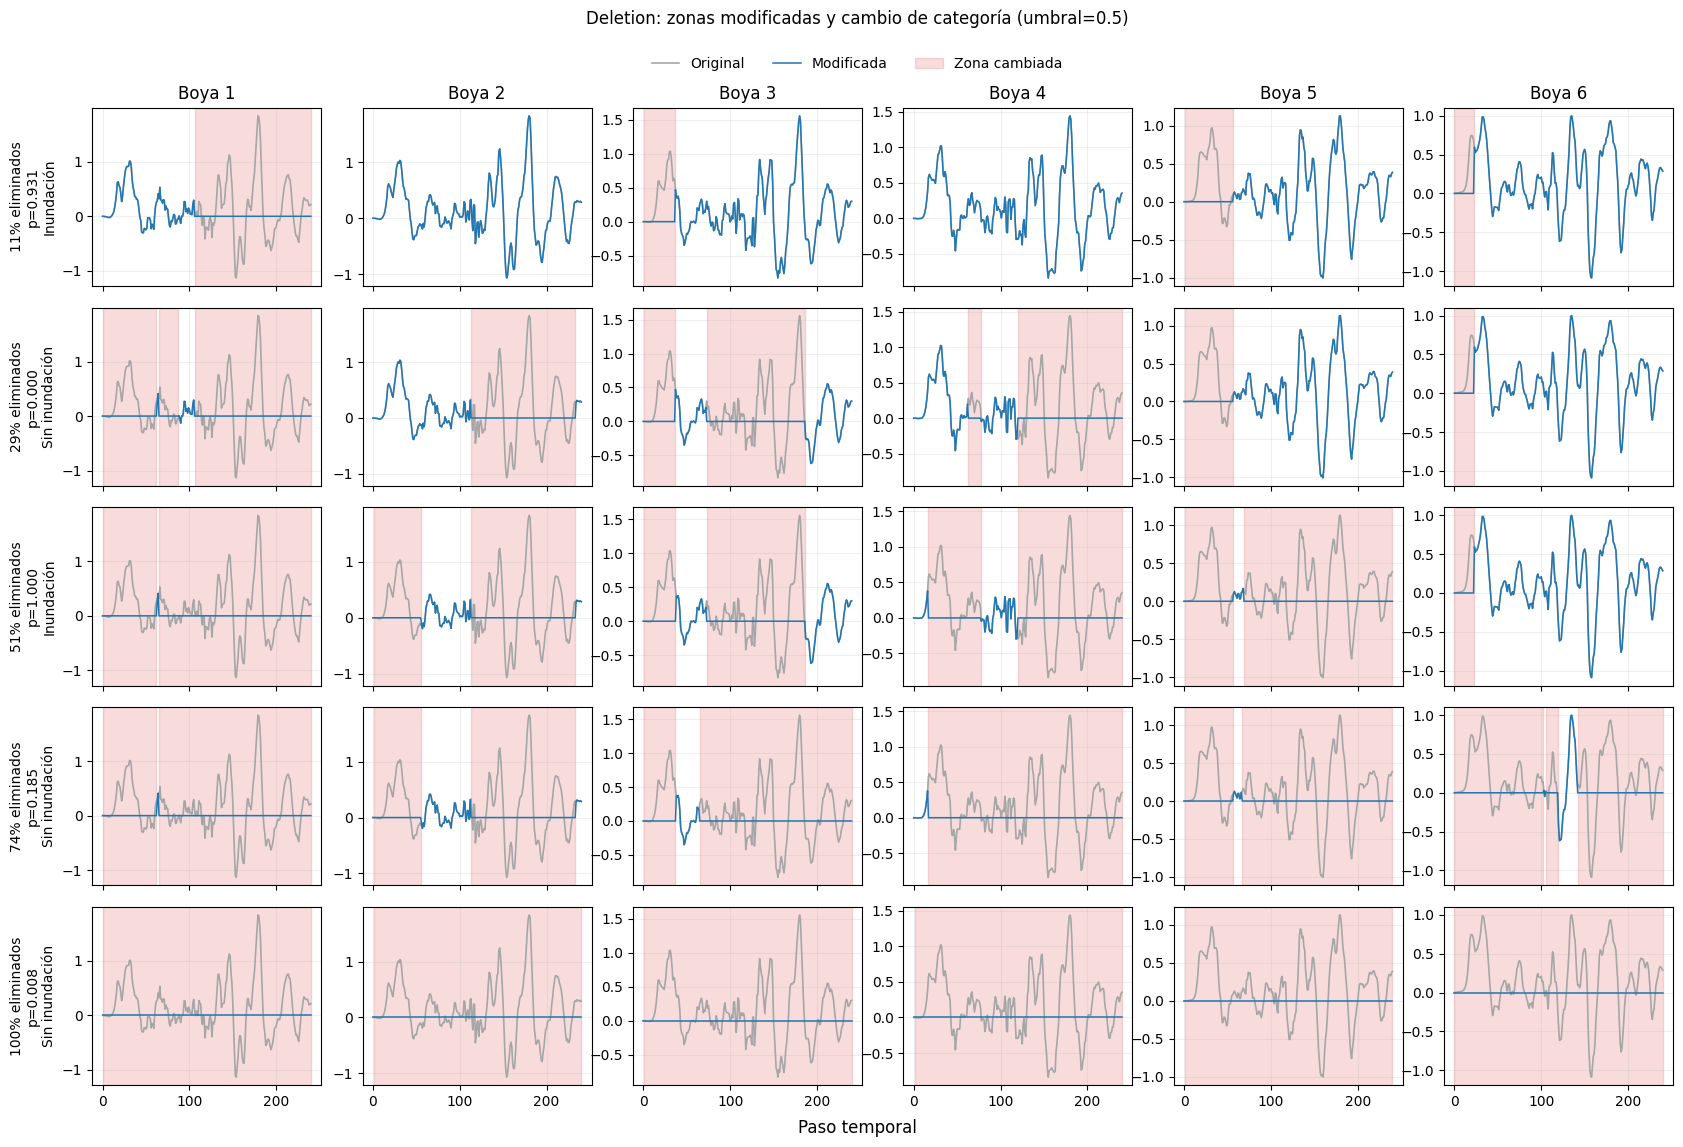

,fracción,probabilidad,categoría
0,0.114286,0.930527,Inundación
1,0.285714,0.000399,Sin inundación
2,0.514286,1.000000,Inundación
3,0.742857,0.185279,Sin inundación
4,1.000000,0.008418,Sin inundación


In [11]:
CLASS_THRESHOLD = 0.5
CLASS_NAMES = ('Sin inundación', 'Inundación')
CHECKPOINTS = (0.10, 0.30, 0.50, 0.75, 1.00)


def predicted_class(probability, threshold=CLASS_THRESHOLD):
    return CLASS_NAMES[int(probability >= threshold)]


def build_segment_steps(x, segment_mask, ordered_labels, mode, replace_method='zeros'):
    baseline = getattr(replacement, replace_method)(x, segment_mask)
    current = x.copy() if mode == 'deletion' else baseline.copy()
    steps = [current.copy()]

    for label in ordered_labels:
        mask = segment_mask == label
        current[mask] = baseline[mask] if mode == 'deletion' else x[mask]
        steps.append(current.copy())

    return np.asarray(steps)


def plot_changed_zones(mode, checkpoints=CHECKPOINTS):
    ordered = fidelity['ordered_labels']
    steps = build_segment_steps(x, segments, ordered, mode, REPLACE_METHOD)
    probabilities = predict_proba(steps)
    indices = sorted(set(int(round(p * len(ordered))) for p in checkpoints))
    color = 'tab:blue' if mode == 'deletion' else 'tab:orange'
    action = 'eliminados' if mode == 'deletion' else 'insertados'

    fig, axes = plt.subplots(
        len(indices), x.shape[1],
        figsize=(3.4 * x.shape[1], 2.3 * len(indices)),
        sharex=True, squeeze=False,
    )

    for row, step_idx in enumerate(indices):
        modified = steps[step_idx]
        probability = probabilities[step_idx]
        changed = ~np.isclose(modified, x)

        for feature, ax in enumerate(axes[row]):
            ax.plot(x[:, feature], color='0.65', linewidth=1.2, label='Original')
            ax.plot(modified[:, feature], color=color, linewidth=1.1, label='Modificada')
            ax.fill_between(
                np.arange(x.shape[0]), 0, 1,
                where=changed[:, feature], color='tab:red', alpha=.16,
                transform=ax.get_xaxis_transform(), label='Zona cambiada',
            )
            ax.grid(alpha=.2)
            if row == 0:
                ax.set_title(feature_names[feature])
            if feature == 0:
                fraction = step_idx / len(ordered)
                ax.set_ylabel(
                    f'{fraction:.0%} {action}\n'
                    f'p={probability:.3f}\n{predicted_class(probability)}'
                )

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(
        handles, labels, loc='upper center', ncol=3, frameon=False,
        bbox_to_anchor=(0.5, 0.965),
    )
    fig.suptitle(
        f'{mode.capitalize()}: zonas modificadas y cambio de categoría '
        f'(umbral={CLASS_THRESHOLD})', y=0.995,
    )
    fig.supxlabel('Paso temporal', y=0.015)
    fig.subplots_adjust(top=0.91, bottom=0.06, hspace=0.12, wspace=0.18)
    plt.show()

    return pd.DataFrame({
        'fracción': np.asarray(indices) / len(ordered),
        'probabilidad': probabilities[indices],
        'categoría': [predicted_class(probabilities[i]) for i in indices],
    })


deletion_changes = plot_changed_zones('deletion')
deletion_changes

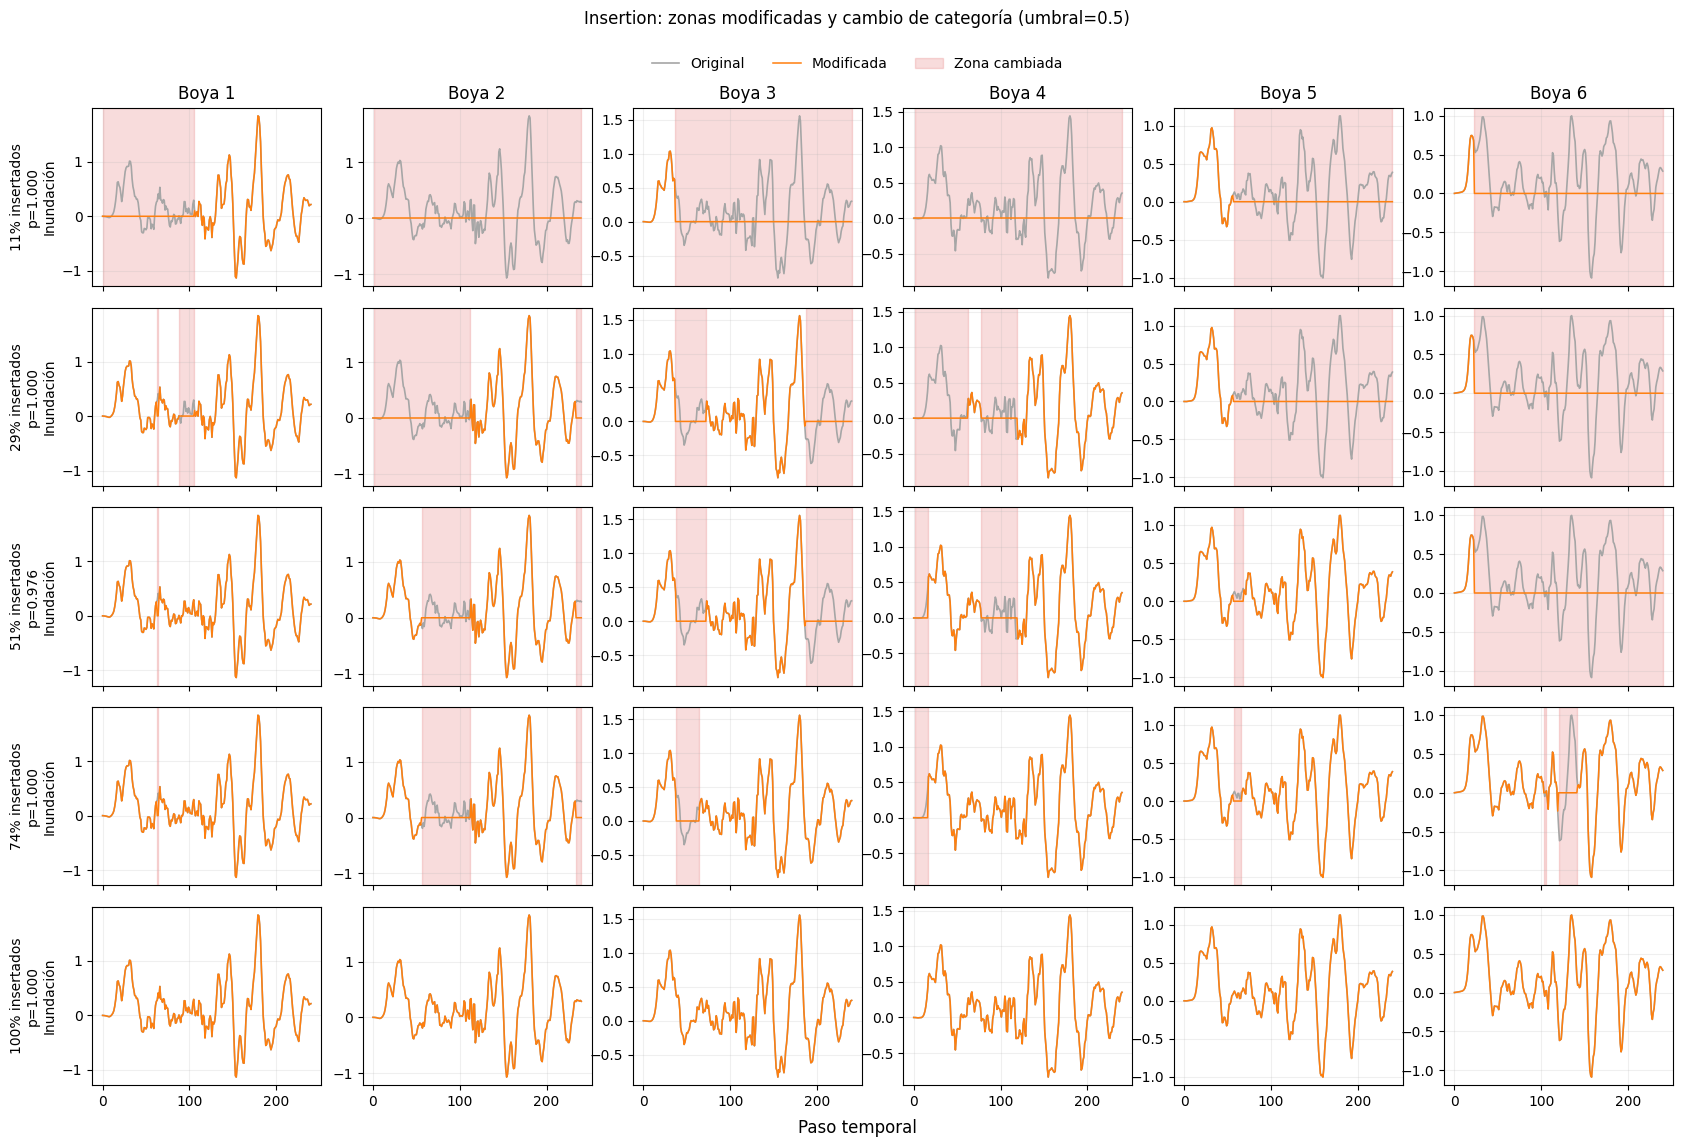

,fracción,probabilidad,categoría
0,0.114286,1.000000,Inundación
1,0.285714,1.000000,Inundación
2,0.514286,0.976457,Inundación
3,0.742857,0.999999,Inundación
4,1.000000,1.000000,Inundación


In [12]:
insertion_changes = plot_changed_zones('insertion')
insertion_changes

### Criterio de lectura

- **R² cercano a 1**: el surrogate reproduce bien al modelo en el vecindario perturbado. Un R² bajo o negativo advierte que los coeficientes no son una aproximación local fiable.
- **Deletion**: debería caer pronto al eliminar los segmentos principales; por eso se prefiere AUC menor.
- **Insertion**: debería subir pronto al restaurar los segmentos principales; por eso se prefiere AUC mayor.
- No existe un umbral universal: compare muestras, configuraciones de segmentación y un orden aleatorio si necesita una prueba estadística posterior.